In [1]:
!pip install -U pip setuptools wheel
!pip install seqeval

  Using cached seqeval-1.2.2.tar.gz (43 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16251 sha256=21421c425d2bd85575dd055bfa162b7a7831a9bc6fb544bdd2141c79819293ba
  Stored in directory: /root/.cache/pip/wheels/14/cf/a7/8f28ef376d707ff10e3922899482a2f23ef3002f8a952f47ac
Successfully built seqeval


In [2]:
import kagglehub
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt


In [6]:
# Download latest version
path = kagglehub.dataset_download("juliangarratt/conll2003-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'conll2003-dataset' dataset.
Path to dataset files: /kaggle/input/conll2003-dataset


In [3]:
with open("/root/.cache/kagglehub/datasets/juliangarratt/conll2003-dataset/versions/1/conll2003/eng.train","r",encoding="utf-8") as f :
  data_train= f.read()

with open("/root/.cache/kagglehub/datasets/juliangarratt/conll2003-dataset/versions/1/conll2003/eng.testa","r",encoding="utf-8") as f :
  data_validation= f.read()

with open("/root/.cache/kagglehub/datasets/juliangarratt/conll2003-dataset/versions/1/conll2003/eng.testb","r",encoding="utf-8") as f :
  data_test= f.read()


## Exploratory Data Analysis


#### number of sentense

In [ ]:
def analyze_dataset(data):
  sentences = data.strip().split("\n\n")
  num_sentences = len(sentences)
  sentence_lengths=[]

  for sentence in sentences:
    tokens = sentence.split("\n")
    sentence_lengths.append(len(tokens))

  num_tokens = sum(sentence_lengths)
  print("Number of sentences:", num_sentences)
  print("Number of tokens:", num_tokens)
  print("Average sentence length:", np.mean(sentence_lengths))
  print("Minimum sentence length:", np.min(sentence_lengths))
  print("Maximum sentence length:", np.max(sentence_lengths))
  print("-" * 40)


analyze_dataset(data_train)
analyze_dataset(data_validation)
analyze_dataset(data_test)



Number of sentences: 14987
Number of tokens: 204567
Average sentence length: 13.649629679055181
Minimum sentence length: 1
Maximum sentence length: 113
----------------------------------------
Number of sentences: 3466
Number of tokens: 51578
Average sentence length: 14.881130986728216
Minimum sentence length: 1
Maximum sentence length: 109
----------------------------------------
Number of sentences: 3684
Number of tokens: 46666
Average sentence length: 12.667209554831704
Minimum sentence length: 1
Maximum sentence length: 124
----------------------------------------


#### Distribution

In [ ]:
sentences = data_train.strip().split("\n\n")
labels=[]


for sentence in sentences:
  lines = sentence.split("\n")

  for line in lines:
    columns= line.split()

    if len(columns)>=4:
      ner_label = columns[3]
      labels.append(ner_label)
print(labels[:20])


['O', 'B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O', 'B-PER', 'I-PER', 'B-LOC', 'O', 'O', 'B-ORG', 'I-ORG', 'O', 'O', 'O']


In [ ]:
sentences = data_train.strip().split("\n\n")
words=[]

for sentence in sentences:
  lines = sentence.split("\n")

  for line in lines:
    columns= line.split()

    if len(columns)>=4:
      ner_label = columns[0]
      words.append(ner_label)
print(words[:20])


['-DOCSTART-', 'EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.', 'Peter', 'Blackburn', 'BRUSSELS', '1996-08-22', 'The', 'European', 'Commission', 'said', 'on', 'Thursday']


In [ ]:
label_counts = Counter(labels)

print("Labels distributions:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Labels distributions:
O: 170524
B-ORG: 6321
B-MISC: 3438
B-PER: 6600
I-PER: 4528
B-LOC: 7140
I-ORG: 3704
I-MISC: 1155
I-LOC: 1157


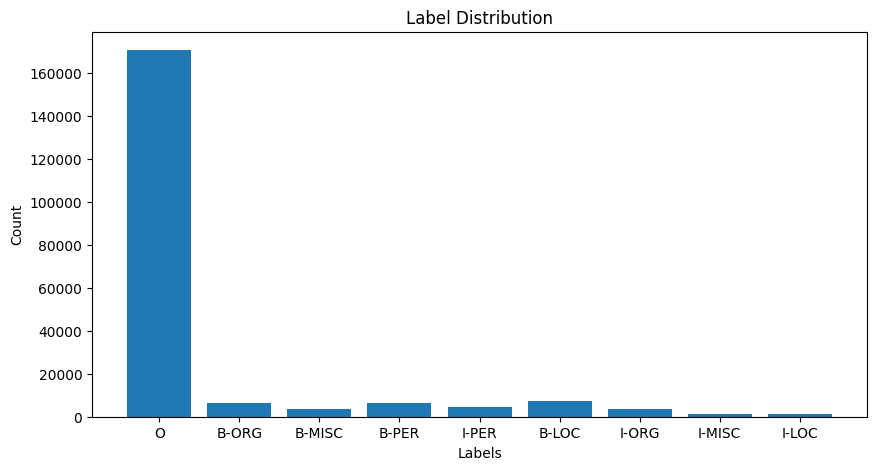

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(label_counts.keys(),label_counts.values())
plt.xlabel("Labels")
plt.ylabel("Count")
plt.title("Label Distribution")
plt.show()


In [ ]:
entity_types=[]

for label in labels:

  if label!= "O":
    entity_type = label.split("-")[1]
    entity_types.append(entity_type)

entity_counts = Counter(entity_types)
print("entity counts")
for entity,count in entity_counts.items():
  print(f"{entity}:{count}")


entity counts
ORG:10025
MISC:4593
PER:11128
LOC:8297


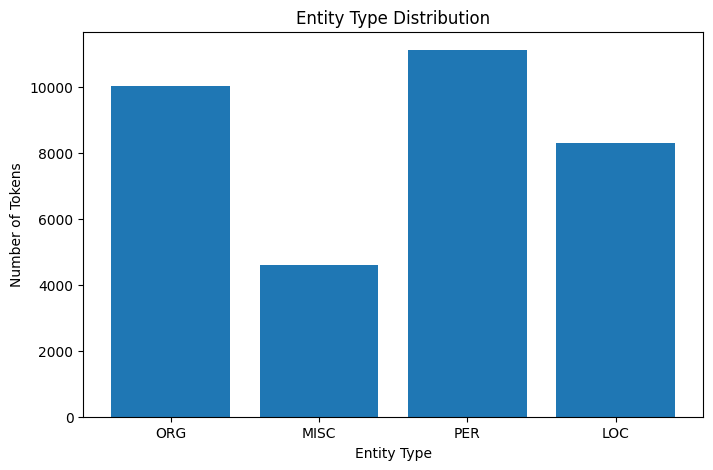

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(entity_counts.keys(), entity_counts.values())

plt.xlabel("Entity Type")
plt.ylabel("Number of Tokens")
plt.title("Entity Type Distribution")

plt.show()

In [ ]:
entities = []

for sentence in sentences:

    current_entity = []
    current_type = None

    for line in sentence.split("\n"):

        columns = line.split()

        if len(columns) < 4:
            continue

        word = columns[0]
        label = columns[3]

        if label.startswith("B-"):

            # Save previous entity
            if current_entity:
                entities.append(
                    (" ".join(current_entity), current_type)
                )

            current_entity = [word]
            current_type = label[2:]

        elif label.startswith("I-"):

            current_entity.append(word)

        else:  # O

            if current_entity:
                entities.append(
                    (" ".join(current_entity), current_type)
                )

                current_entity = []
                current_type = None

    # Save entity at end of sentence
    if current_entity:
        entities.append(
            (" ".join(current_entity), current_type)
        )

print(entities[:20])

[('EU', 'ORG'), ('German', 'MISC'), ('British', 'MISC'), ('Peter Blackburn', 'PER'), ('BRUSSELS', 'LOC'), ('European Commission', 'ORG'), ('German', 'MISC'), ('British', 'MISC'), ('Germany', 'LOC'), ('European Union', 'ORG'), ('Werner Zwingmann', 'PER'), ('Britain', 'LOC'), ('Commission', 'ORG'), ('Nikolaus van der Pas', 'PER'), ('European Union', 'ORG'), ('EU', 'ORG'), ('Franz Fischler', 'PER'), ('Fischler', 'PER'), ('EU-wide', 'MISC'), ('Britain', 'LOC')]


In [ ]:
entity_frequency = Counter(
    entity[0] for entity in entities
)

print(entity_frequency.most_common(10))


[('U.S.', 303), ('Germany', 141), ('Britain', 133), ('Australia', 130), ('England', 123), ('France', 122), ('Spain', 110), ('Italy', 98), ('NEW YORK', 95), ('LONDON', 93)]


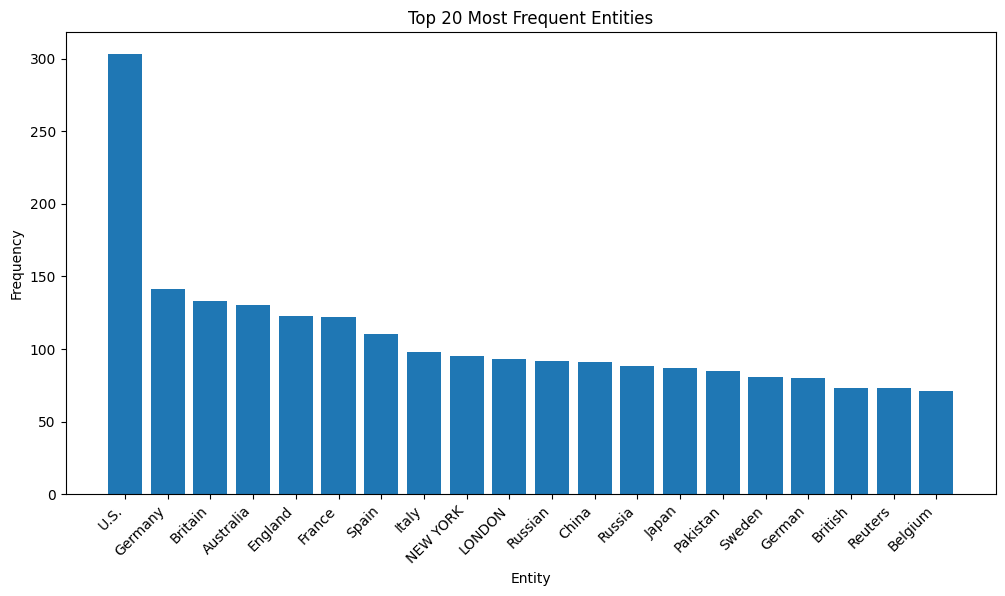

In [ ]:
top_entities = entity_frequency.most_common(20)

names = [x[0] for x in top_entities]
counts = [x[1] for x in top_entities]

plt.figure(figsize=(12, 6))

plt.bar(names, counts)

plt.xlabel("Entity")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Entities")

plt.xticks(rotation=45, ha="right")

plt.show()

In [ ]:
entity_lengths = []

for entity, entity_type in entities:

    length = len(entity.split())

    entity_lengths.append(length)

print(entity_lengths[:20])

[1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1, 1, 4, 2, 1, 2, 1, 1, 1]


In [ ]:
print("Average entity length:", np.mean(entity_lengths))
print("Minimum entity length:", np.min(entity_lengths))
print("Maximum entity length:", np.max(entity_lengths))

Average entity length: 1.448699944678497
Minimum entity length: 1
Maximum entity length: 10


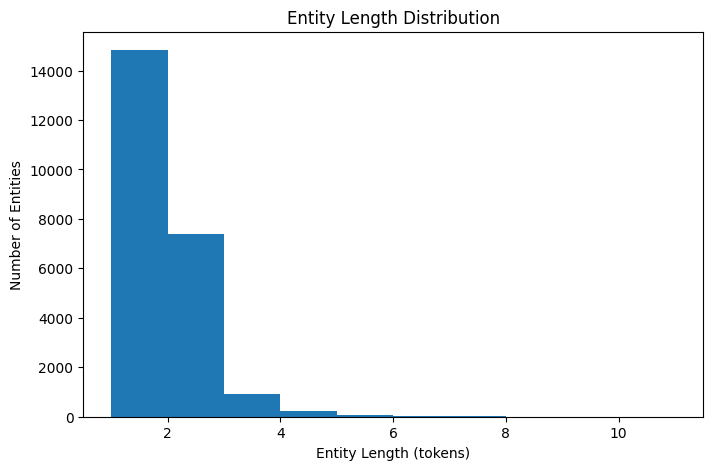

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(entity_lengths, bins=range(1, max(entity_lengths) + 2))

plt.xlabel("Entity Length (tokens)")
plt.ylabel("Number of Entities")
plt.title("Entity Length Distribution")

plt.show()

#### Linguistic Analysis


In [ ]:
words = []
for sentence in sentences:
    for line in sentence.split("\n"):

        columns = line.split()

        if len(columns) >= 4:
            word = columns[0]
            words.append(word.lower())

word_frequency = Counter(words)

print(word_frequency.most_common(20))

[('the', 8390), ('.', 7374), (',', 7290), ('of', 3815), ('in', 3621), ('to', 3424), ('a', 3199), ('and', 2872), ('(', 2861), (')', 2861), ('"', 2178), ('on', 2092), ('said', 1849), ("'s", 1566), ('for', 1465), ('1', 1421), ('-', 1243), ('at', 1146), ('was', 1095), ('2', 973)]


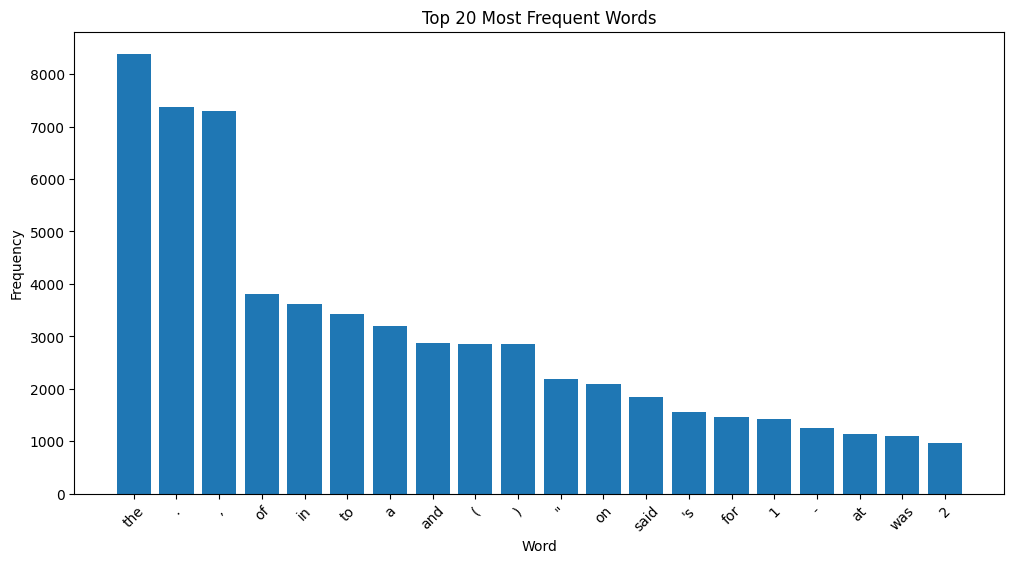

In [ ]:
import matplotlib.pyplot as plt

top_words = word_frequency.most_common(20)

words_names = [x[0] for x in top_words]
words_counts = [x[1] for x in top_words]

plt.figure(figsize=(12, 6))

plt.bar(words_names, words_counts)

plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Words")

plt.xticks(rotation=45)

plt.show()

#### POS Tag Distribution

In [ ]:
pos_tags = []

for sentence in sentences:
    for line in sentence.split("\n"):

        columns = line.split()

        if len(columns) >= 4:
            pos = columns[1]
            pos_tags.append(pos)

pos_frequency = Counter(pos_tags)

print(pos_frequency.most_common(10))

[('NNP', 34392), ('NN', 23899), ('CD', 19704), ('IN', 19064), ('DT', 13453), ('JJ', 11831), ('NNS', 9903), ('VBD', 8293), ('.', 7389), (',', 7291)]


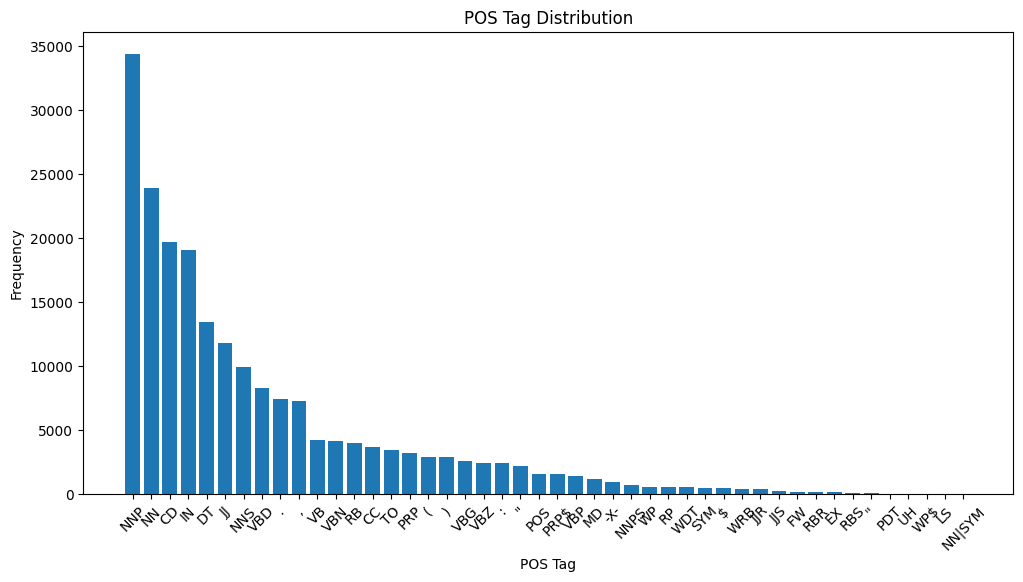

In [ ]:
top_pos = pos_frequency.most_common()

pos_names = [x[0] for x in top_pos]
pos_counts = [x[1] for x in top_pos]

plt.figure(figsize=(12, 6))

plt.bar(pos_names, pos_counts)

plt.xlabel("POS Tag")
plt.ylabel("Frequency")
plt.title("POS Tag Distribution")

plt.xticks(rotation=45)

plt.show()

#### Data Quality

In [ ]:
empty_sentences = 0

for sentence in sentences:

    if len(sentence.strip()) == 0:
        empty_sentences += 1

print("Empty sentences:", empty_sentences)

Empty sentences: 0


#### Missing values

In [ ]:
invalid_lines = []

for sentence in sentences:

    for line in sentence.split("\n"):

        columns = line.split()

        if len(columns) < 4:
            invalid_lines.append(line)

print("Invalid lines:", len(invalid_lines))

Invalid lines: 0


#### Duplicates

In [ ]:
from collections import Counter

sentence_strings = [
    sentence.strip()
    for sentence in sentences
]

counts = Counter(sentence_strings)

duplicates = {
    sentence: count
    for sentence, count in counts.items()
    if count > 1
}

print("Number of duplicated sentences:", len(duplicates))

for sentence, count in list(duplicates.items())[:5]:
    print("Appears:", count, "times")
    print(sentence)
    print("-" * 50)

Number of duplicated sentences: 721
Appears: 946 times
-DOCSTART- -X- -X- O
--------------------------------------------------
Appears: 2 times
BRUSSELS NNP B-NP B-LOC
1996-08-22 CD I-NP O
--------------------------------------------------
Appears: 3 times
. . O O
--------------------------------------------------
Appears: 2 times
It PRP B-NP O
brought VBD B-VP O
in IN B-PP O
4,275 CD B-NP O
tonnes NNS I-NP O
of IN B-PP O
British JJ B-NP B-MISC
mutton NN I-NP O
, , O O
some DT B-NP O
10 CD I-NP O
percent NN I-NP O
of IN B-PP O
overall JJ B-NP O
imports NNS I-NP O
. . O O
--------------------------------------------------
Appears: 12 times
LONDON NNP B-NP B-LOC
1996-08-22 CD I-NP O
--------------------------------------------------


#### BIO consistency

In [ ]:
invalid_bio = []

for sentence in sentences:

    previous_label = "O"

    for line in sentence.split("\n"):

        columns = line.split()

        if len(columns) < 4:
            continue

        word = columns[0]
        label = columns[3]

        if label.startswith("I-"):

            entity_type = label[2:]

            # Previous token must be B-type or I-same-type
            if previous_label not in [
                "B-" + entity_type,
                "I-" + entity_type
            ]:
                invalid_bio.append((word, label))

        previous_label = label

print("Invalid BIO labels:", len(invalid_bio))

Invalid BIO labels: 0


## Tokenization

In [4]:
def load_conll(path):

    sentences = []

    with open(path, "r", encoding="utf-8") as f:

        tokens = []
        labels = []

        for line in f:

            line = line.strip()
            if line.startswith("-DOCSTART-"):
              continue
            # Empty line = end of sentence
            if not line:

                if tokens:
                    sentences.append({
                        "tokens": tokens,
                        "labels": labels
                    })

                tokens = []
                labels = []

            else:

                columns = line.split()

                if len(columns) >= 4:
                    word = columns[0]
                    ner_label = columns[3]

                    tokens.append(word)
                    labels.append(ner_label)

        if tokens:
            sentences.append({
                "tokens": tokens,
                "labels": labels
            })

    return sentences

In [7]:
data_train=load_conll("/kaggle/input/conll2003-dataset/conll2003/eng.train")
data_validation=load_conll("/kaggle/input/conll2003-dataset/conll2003/eng.testa")
data_test=load_conll("/kaggle/input/conll2003-dataset/conll2003/eng.testb")

In [18]:
print(data_test[8])
print(data_test[8])

{'tokens': ['Despite', 'winning', 'the', 'Asian', 'Games', 'title', 'two', 'years', 'ago', ',', 'Uzbekistan', 'are', 'in', 'the', 'finals', 'as', 'outsiders', '.'], 'labels': ['O', 'O', 'O', 'B-MISC', 'I-MISC', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O']}
{'tokens': ['Despite', 'winning', 'the', 'Asian', 'Games', 'title', 'two', 'years', 'ago', ',', 'Uzbekistan', 'are', 'in', 'the', 'finals', 'as', 'outsiders', '.'], 'labels': ['O', 'O', 'O', 'B-MISC', 'I-MISC', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O']}


In [13]:
for token, label in zip(data_test[:8], data_test[:8]):
    print(token, "->", label)

{'tokens': ['SOCCER', '-', 'JAPAN', 'GET', 'LUCKY', 'WIN', ',', 'CHINA', 'IN', 'SURPRISE', 'DEFEAT', '.'], 'labels': ['O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'B-PER', 'O', 'O', 'O', 'O']} -> {'tokens': ['SOCCER', '-', 'JAPAN', 'GET', 'LUCKY', 'WIN', ',', 'CHINA', 'IN', 'SURPRISE', 'DEFEAT', '.'], 'labels': ['O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'B-PER', 'O', 'O', 'O', 'O']}
{'tokens': ['Nadim', 'Ladki'], 'labels': ['B-PER', 'I-PER']} -> {'tokens': ['Nadim', 'Ladki'], 'labels': ['B-PER', 'I-PER']}
{'tokens': ['AL-AIN', ',', 'United', 'Arab', 'Emirates', '1996-12-06'], 'labels': ['B-LOC', 'O', 'B-LOC', 'I-LOC', 'I-LOC', 'O']} -> {'tokens': ['AL-AIN', ',', 'United', 'Arab', 'Emirates', '1996-12-06'], 'labels': ['B-LOC', 'O', 'B-LOC', 'I-LOC', 'I-LOC', 'O']}
{'tokens': ['Japan', 'began', 'the', 'defence', 'of', 'their', 'Asian', 'Cup', 'title', 'with', 'a', 'lucky', '2-1', 'win', 'against', 'Syria', 'in', 'a', 'Group', 'C', 'championship', 'match', 'on', 'Friday', '.'], 'labels': ['B-LOC',

In [16]:
print(data_train[:3])

[{'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'labels': ['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']}, {'tokens': ['Peter', 'Blackburn'], 'labels': ['B-PER', 'I-PER']}, {'tokens': ['BRUSSELS', '1996-08-22'], 'labels': ['B-LOC', 'O']}]


In [17]:
from datasets import Dataset

data_train = Dataset.from_list(data_train)
data_validation = Dataset.from_list(data_validation)
data_test = Dataset.from_list(data_test)

In [20]:
unique_val=set()

for label in data_train["labels"]:
  unique_val.update(label)
print(unique_val)

{'B-PER', 'B-LOC', 'B-MISC', 'O', 'I-MISC', 'I-ORG', 'I-PER', 'B-ORG', 'I-LOC'}


In [21]:
label2id={
    label: i
    for i, label in enumerate(sorted(unique_val))

}
print(label2id)

{'B-LOC': 0, 'B-MISC': 1, 'B-ORG': 2, 'B-PER': 3, 'I-LOC': 4, 'I-MISC': 5, 'I-ORG': 6, 'I-PER': 7, 'O': 8}


In [22]:
id2label = {
    i: label
    for label, i in label2id.items()
}

print(id2label)

{0: 'B-LOC', 1: 'B-MISC', 2: 'B-ORG', 3: 'B-PER', 4: 'I-LOC', 5: 'I-MISC', 6: 'I-ORG', 7: 'I-PER', 8: 'O'}


In [23]:
import transformers
from transformers import AutoTokenizer
model_checkpoint = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
#to search about
assert isinstance(tokenizer, transformers.PreTrainedTokenizerFast)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [53]:
def tokenize_and_align_labels(examples):

    # 1. Tokenization
    tokenized_inputs = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True
    )

    all_labels = []

    # 2. Process each sentence
    for i, sentence_labels in enumerate(examples["labels"]):

        # Get the original word index for each token
        word_ids = tokenized_inputs.word_ids(batch_index=i)

        label_ids = []
        previous_word_id = None

        # 3. Align labels with tokens
        for word_id in word_ids:

            # [CLS], [SEP], padding...
            if word_id is None:
                label_ids.append(-100)

            # First subword of a word
            elif word_id != previous_word_id:
                label_ids.append(
                    label2id[sentence_labels[word_id]]
                )

            # Other subwords of the same word
            else:
                label_ids.append(-100)

            previous_word_id = word_id

        all_labels.append(label_ids)

    # 4. Add aligned labels to tokenizer output
    tokenized_inputs["labels"] = all_labels

    return tokenized_inputs

In [54]:
tokenized_train = data_train.map(
    tokenize_and_align_labels,
    batched=True
)

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

In [55]:
tokenized_validation = data_validation.map(
    tokenize_and_align_labels,
    batched=True
)

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

In [56]:
tokenized_test = data_test.map(
    tokenize_and_align_labels,
    batched=True
)

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

In [57]:
print(len(tokenized_test))
print(tokenized_test[3])

3453
{'tokens': ['Japan', 'began', 'the', 'defence', 'of', 'their', 'Asian', 'Cup', 'title', 'with', 'a', 'lucky', '2-1', 'win', 'against', 'Syria', 'in', 'a', 'Group', 'C', 'championship', 'match', 'on', 'Friday', '.'], 'labels': [-100, 0, 8, 8, 8, 8, 8, 1, 5, 8, 8, 8, 8, 8, -100, -100, 8, 8, 0, 8, 8, 8, 8, 8, 8, 8, 8, 8, -100], 'input_ids': [101, 2900, 2211, 1996, 4721, 1997, 2037, 4004, 2452, 2516, 2007, 1037, 5341, 1016, 1011, 1015, 2663, 2114, 7795, 1999, 1037, 2177, 1039, 2528, 2674, 2006, 5958, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [58]:
print(tokenized_train[:6])

for token, label in zip(tokenized_train[:6], data_train[:6]):
    print(token, "->", label)

{'tokens': [['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], ['Peter', 'Blackburn'], ['BRUSSELS', '1996-08-22'], ['The', 'European', 'Commission', 'said', 'on', 'Thursday', 'it', 'disagreed', 'with', 'German', 'advice', 'to', 'consumers', 'to', 'shun', 'British', 'lamb', 'until', 'scientists', 'determine', 'whether', 'mad', 'cow', 'disease', 'can', 'be', 'transmitted', 'to', 'sheep', '.'], ['Germany', "'s", 'representative', 'to', 'the', 'European', 'Union', "'s", 'veterinary', 'committee', 'Werner', 'Zwingmann', 'said', 'on', 'Wednesday', 'consumers', 'should', 'buy', 'sheepmeat', 'from', 'countries', 'other', 'than', 'Britain', 'until', 'the', 'scientific', 'advice', 'was', 'clearer', '.'], ['"', 'We', 'do', "n't", 'support', 'any', 'such', 'recommendation', 'because', 'we', 'do', "n't", 'see', 'any', 'grounds', 'for', 'it', ',', '"', 'the', 'Commission', "'s", 'chief', 'spokesman', 'Nikolaus', 'van', 'der', 'Pas', 'told', 'a', 'news', 'briefing', '.']], 

## Training model

In [59]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [122]:
print(model.num_labels)

9


In [60]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,
    label_pad_token_id=-100
)

In [61]:
import numpy as np
from seqeval.metrics import precision_score, recall_score, f1_score, accuracy_score


def compute_metrics(eval_prediction):

    predictions, labels = eval_prediction

    # Get predicted label IDs
    predictions = np.argmax(predictions, axis=2)

    true_labels = []
    true_predictions = []

    for prediction, label in zip(predictions, labels):

        sentence_labels = []
        sentence_predictions = []

        for pred_id, label_id in zip(prediction, label):

            # Ignore special tokens / subword tokens
            if label_id == -100:
                continue

            sentence_labels.append(id2label[label_id])
            sentence_predictions.append(id2label[pred_id])

        true_labels.append(sentence_labels)
        true_predictions.append(sentence_predictions)

    return {
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
        "accuracy": accuracy_score(true_labels, true_predictions)
    }

In [62]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir = "./ner_model",
    learning_rate=2e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)


In [63]:
from transformers import Trainer,EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,

    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],


)

In [64]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Model device:", model.device)

GPU available: True
GPU: Tesla T4
Model device: cuda:0


In [65]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.125580,0.089719,0.879508,0.878324,0.878915,0.975936
2,0.033423,0.063322,0.911580,0.929990,0.920693,0.984035
3,0.010539,0.065136,0.928655,0.937563,0.933088,0.985865


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2634, training_loss=0.048722924702802935, metrics={'train_runtime': 270.6025, 'train_samples_per_second': 155.664, 'train_steps_per_second': 9.734, 'total_flos': 510122266253334.0, 'train_loss': 0.048722924702802935, 'epoch': 3.0})

In [66]:
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Precision,Recall,F1,Accuracy
0.010539,0.063322,3,0.911580,0.929990,0.920693,0.984035


{'eval_loss': 0.0633215606212616, 'eval_precision': 0.9115803365225998, 'eval_recall': 0.9299899023897678, 'eval_f1': 0.9206931022992336, 'eval_accuracy': 0.9840348896071025}


In [67]:
predictions = trainer.predict(tokenized_test)

import numpy as np

logits = predictions.predictions
true_labels = predictions.label_ids

pred_ids = np.argmax(logits, axis=-1)

In [68]:
true_labels_clean = []
pred_labels_clean = []

for pred_sentence, true_sentence in zip(pred_ids, true_labels):

    true_sentence_labels = []
    pred_sentence_labels = []

    for pred_id, true_id in zip(pred_sentence, true_sentence):

        if true_id == -100:
            continue

        true_sentence_labels.append(id2label[true_id])
        pred_sentence_labels.append(id2label[pred_id])

    true_labels_clean.append(true_sentence_labels)
    pred_labels_clean.append(pred_sentence_labels)

In [69]:
from seqeval.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

precision = precision_score(
    true_labels_clean,
    pred_labels_clean
)

recall = recall_score(
    true_labels_clean,
    pred_labels_clean
)

f1 = f1_score(
    true_labels_clean,
    pred_labels_clean
)

print("Test Precision:", precision)
print("Test Recall:", recall)
print("Test F1:", f1)

print("\nTest Classification Report:")
print(classification_report(
    true_labels_clean,
    pred_labels_clean
))

Test Precision: 0.866516620498615
Test Recall: 0.8861543909348442
Test F1: 0.8762254901960784

Test Classification Report:
              precision    recall  f1-score   support

         LOC       0.89      0.93      0.91      1668
        MISC       0.70      0.75      0.72       702
         ORG       0.86      0.83      0.84      1661
         PER       0.93      0.96      0.95      1617

   micro avg       0.87      0.89      0.88      5648
   macro avg       0.84      0.87      0.85      5648
weighted avg       0.87      0.89      0.88      5648



## Analyse Errors

In [146]:
for sentence in data_test:

    tokens = sentence["tokens"]
    labels = sentence["labels"]

    if "world" in tokens:
      if "cup" in tokens:

        for token, label in zip(tokens, labels):
            print(token, "->", label)

China -> B-LOC
made -> O
a -> O
promising -> O
debut -> O
on -> O
the -> O
freestyle -> O
skiing -> O
world -> O
cup -> O
circuit -> O
in -> O
an -> O
aerials -> O
event -> O
in -> O
the -> O
French -> B-MISC
resort -> O
of -> O
Tignes -> B-LOC
on -> O
Saturday -> O
. -> O


In [145]:
for sentence in tokenized_test:

    tokens = sentence["tokens"]
    labels = sentence["labels"]

    if "world" in tokens:
      if "cup" in tokens:

        for token, label in zip(tokens, labels):
            print(token, "->", label)

[CLS] -> -100
japan -> 0
, -> 8
co -> 8
- -> -100
hosts -> -100
of -> 8
the -> 8
world -> 1
cup -> 5
in -> 8
2002 -> 8
and -> 8
ranked -> 8
20th -> 8
in -> 8
the -> 8
world -> 8
by -> 8
fifa -> 2
, -> 8
are -> 8
favourites -> 8
to -> 8
regain -> 8
their -> 8
title -> 8
here -> 8
. -> 8
[SEP] -> -100
[CLS] -> -100
cut -> 3
##ti -> -100
##tta -> -100
announced -> 8
his -> 8
retirement -> 8
after -> 8
the -> 8
1995 -> 1
world -> 5
cup -> 5
, -> 8
where -> 8
he -> 8
took -> 8
issue -> 8
with -> 8
being -> 8
dropped -> 8
from -> 8
the -> 8
italy -> 0
side -> 8
that -> 8
faced -> 8
england -> 0
in -> 8
the -> 8
pool -> 8
stages -> 8
. -> 8
[SEP] -> -100
[CLS] -> -100
" -> 8
he -> 8
ended -> 8
the -> 8
world -> 1
cup -> 5
on -> 8
the -> 8
wrong -> 8
note -> 8
, -> 8
" -> 8
cost -> 3
##e -> -100
said -> 8
. -> 8
[SEP] -> -100
[CLS] -> -100
freestyle -> 8
skiing -> 1
- -> -100
world -> -100
cup -> 5
mo -> 8
##gul -> -100
results -> 8
. -> 8
[SEP] -> -100
[CLS] -> -100
results -> 8
of -> 8
the -

In [137]:
count = 0

for tokens, true_labels, pred_labels in zip(
    tokenized_test,
    true_labels_clean,
    pred_labels_clean
):

    for token, true_label, pred_label in zip(
        tokens, true_labels, pred_labels
    ):

        if "MISC" in true_label or "MISC" in pred_label:

            if true_label != pred_label:

                print(
                    f"Token: {token:20} "
                    f"True: {true_label:10} "
                    f"Pred: {pred_label}"
                )

                count += 1

                if count >= 30:
                    break

    if count >= 30:
        break

Token: attention_mask       True: B-MISC     Pred: B-LOC
Token: tokens               True: B-MISC     Pred: O
Token: labels               True: I-MISC     Pred: B-MISC
Token: input_ids            True: B-ORG      Pred: B-MISC
Token: attention_mask       True: B-ORG      Pred: B-MISC
Token: labels               True: I-ORG      Pred: I-MISC
Token: input_ids            True: O          Pred: B-MISC
Token: tokens               True: O          Pred: I-MISC
Token: input_ids            True: O          Pred: B-MISC
Token: tokens               True: O          Pred: I-MISC
Token: input_ids            True: B-LOC      Pred: B-MISC
Token: tokens               True: O          Pred: I-MISC
Token: input_ids            True: O          Pred: B-MISC
Token: tokens               True: O          Pred: I-MISC
Token: input_ids            True: B-LOC      Pred: B-MISC
Token: tokens               True: O          Pred: I-MISC
Token: input_ids            True: B-ORG      Pred: B-MISC
Token: attention_mas

In [138]:
from collections import Counter

misc_errors = Counter()

for true_sentence, pred_sentence in zip(
    true_labels_clean,
    pred_labels_clean
):

    for true_label, pred_label in zip(
        true_sentence,
        pred_sentence
    ):

        if true_label != pred_label:

            if true_label == "B-MISC":
                misc_errors[pred_label] += 1

            elif pred_label == "I-MISC":
                misc_errors[true_label] += 1

print(misc_errors)

Counter({'O': 130, 'B-ORG': 32, 'B-LOC': 31, 'I-ORG': 16, 'I-MISC': 7, 'B-PER': 6, 'I-PER': 1})


In [139]:
from collections import Counter

all_true = []

for sentence in true_labels_clean:
    all_true.extend(sentence)

print("Nombre total de labels :", len(all_true))
print(Counter(all_true))

Nombre total de labels : 46435
Counter({'O': 38323, 'B-LOC': 1668, 'B-ORG': 1661, 'B-PER': 1617, 'I-PER': 1156, 'I-ORG': 835, 'B-MISC': 702, 'I-LOC': 257, 'I-MISC': 216})


In [140]:
from collections import Counter

misc_errors = Counter()

for true_sentence, pred_sentence in zip(
    true_labels_clean,
    pred_labels_clean
):

    for true_label, pred_label in zip(
        true_sentence,
        pred_sentence
    ):

        if true_label in ["B-MISC", "I-MISC"] and true_label != pred_label:
            misc_errors[(true_label, pred_label)] += 1

print(misc_errors)

Counter({('B-MISC', 'O'): 48, ('B-MISC', 'B-LOC'): 31, ('B-MISC', 'B-ORG'): 31, ('I-MISC', 'O'): 21, ('I-MISC', 'I-ORG'): 12, ('I-MISC', 'I-LOC'): 8, ('B-MISC', 'I-MISC'): 7, ('B-MISC', 'B-PER'): 6, ('I-MISC', 'B-MISC'): 4, ('I-MISC', 'I-PER'): 2, ('I-MISC', 'B-ORG'): 1, ('B-MISC', 'I-ORG'): 1, ('I-MISC', 'B-LOC'): 1})


In [38]:
# Vérifier les colonnes
print(tokenized_test.column_names)

['tokens', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [39]:
test_tokens = tokenized_test["tokens"]

print(test_tokens[0])

['SOCCER', '-', 'JAPAN', 'GET', 'LUCKY', 'WIN', ',', 'CHINA', 'IN', 'SURPRISE', 'DEFEAT', '.']


In [141]:
count = 0

for tokens, true_sentence, pred_sentence in zip(
    test_tokens,
    true_labels_clean,
    pred_labels_clean
):

    errors = []

    for token, true_label, pred_label in zip(
        tokens,
        true_sentence,
        pred_sentence
    ):

        # On affiche uniquement les erreurs impliquant MISC
        if (
            true_label in ["B-MISC", "I-MISC"]
            or pred_label in ["B-MISC", "I-MISC"]
        ) and true_label != pred_label:

            errors.append(
                (token, true_label, pred_label)
            )

    if errors:

        print("\nSentence:")
        print(" ".join(tokens))

        print("\nErrors:")
        print(f"{'Token':20} {'True':12} {'Predicted':12}")

        for token, true_label, pred_label in errors:
            print(f"{token:20} {true_label:12} {pred_label:12}")

        print("-" * 70)

        count += 1

        if count >= 20:
            break


Sentence:
The former Soviet republic was playing in an Asian Cup finals tie for the first time .

Errors:
Token                True         Predicted   
Soviet               B-MISC       B-LOC       
----------------------------------------------------------------------

Sentence:
Cuttitta announced his retirement after the 1995 World Cup , where he took issue with being dropped from the Italy side that faced England in the pool stages .

Errors:
Token                True         Predicted   
World                I-MISC       B-MISC      
----------------------------------------------------------------------

Sentence:
FREESTYLE SKIING-WORLD CUP MOGUL RESULTS .

Errors:
Token                True         Predicted   
SKIING-WORLD         B-MISC       O           
----------------------------------------------------------------------

Sentence:
SOCCER - ENGLISH F.A. CUP SECOND ROUND RESULT .

Errors:
Token                True         Predicted   
F.A.                 I-MISC       B-MISC

In [ ]:
id2label = {v: k for k, v in label2id.items()}

print([
    (token, id2label[label] if label != -100 else "-100")
    for token, label in zip(tokens, labels)
])

[('The', '-100'), ('lanky', 'O'), ('former', 'O'), ('Leeds', '-100'), ('United', 'O'), ('defender', 'B-ORG'), ('did', 'I-ORG'), ('not', 'O'), ('make', 'O'), ('his', 'O'), ('England', 'O'), ('debut', 'O'), ('until', 'B-LOC'), ('the', 'O'), ('age', 'O'), ('of', 'O'), ('30', 'O'), ('but', 'O'), ('eventually', 'O'), ('won', 'O'), ('35', 'O'), ('caps', 'O'), ('and', 'O'), ('was', 'O'), ('a', 'O'), ('key', 'O'), ('member', 'O'), ('of', 'O'), ('the', 'O'), ('1966', 'O'), ('World', 'O'), ('Cup', 'B-MISC'), ('winning', 'I-MISC'), ('team', 'I-MISC'), ('with', 'O'), ('his', 'O'), ('younger', 'O'), ('brother', 'O'), (',', 'O'), ('Bobby', 'O'), ('.', 'O')]


In [ ]:
for tokens, labels in zip(tokenized_test["tokens"], tokenized_test["labels"]):
    if "World" in tokens:
        print(list(zip(tokens, labels)))

[('Japan', -100), (',', 0), ('co-hosts', 8), ('of', 8), ('the', -100), ('World', -100), ('Cup', 8), ('in', 8), ('2002', 1), ('and', 5), ('ranked', 8), ('20th', 8), ('in', 8), ('the', 8), ('world', 8), ('by', 8), ('FIFA', 8), (',', 8), ('are', 8), ('favourites', 2), ('to', 8), ('regain', 8), ('their', 8), ('title', 8), ('here', 8), ('.', 8)]
[('Cuttitta', -100), ('announced', 3), ('his', -100), ('retirement', -100), ('after', 8), ('the', 8), ('1995', 8), ('World', 8), ('Cup', 8), (',', 1), ('where', 5), ('he', 5), ('took', 8), ('issue', 8), ('with', 8), ('being', 8), ('dropped', 8), ('from', 8), ('the', 8), ('Italy', 8), ('side', 8), ('that', 8), ('faced', 0), ('England', 8), ('in', 8), ('the', 8), ('pool', 0), ('stages', 8), ('.', 8)]
[('"', -100), ('He', 8), ('ended', 8), ('the', 8), ('World', 8), ('Cup', 1), ('on', 5), ('the', 8), ('wrong', 8), ('note', 8), (',', 8), ('"', 8), ('Coste', 8), ('said', 3), ('.', -100)]
[('Results', -100), ('of', 8), ('the', 8), ('World', 8), ('Cup', 1)]

In [ ]:
for tokens, labels in zip(tokenized_test["tokens"], tokenized_test["labels"]):
    if "World" in tokens:
        print(list(zip(tokens, labels)))

[('Japan', -100), (',', 0), ('co-hosts', 8), ('of', 8), ('the', -100), ('World', -100), ('Cup', 8), ('in', 8), ('2002', 1), ('and', 5), ('ranked', 8), ('20th', 8), ('in', 8), ('the', 8), ('world', 8), ('by', 8), ('FIFA', 8), (',', 8), ('are', 8), ('favourites', 2), ('to', 8), ('regain', 8), ('their', 8), ('title', 8), ('here', 8), ('.', 8)]
[('Cuttitta', -100), ('announced', 3), ('his', -100), ('retirement', -100), ('after', 8), ('the', 8), ('1995', 8), ('World', 8), ('Cup', 8), (',', 1), ('where', 5), ('he', 5), ('took', 8), ('issue', 8), ('with', 8), ('being', 8), ('dropped', 8), ('from', 8), ('the', 8), ('Italy', 8), ('side', 8), ('that', 8), ('faced', 0), ('England', 8), ('in', 8), ('the', 8), ('pool', 0), ('stages', 8), ('.', 8)]
[('"', -100), ('He', 8), ('ended', 8), ('the', 8), ('World', 8), ('Cup', 1), ('on', 5), ('the', 8), ('wrong', 8), ('note', 8), (',', 8), ('"', 8), ('Coste', 8), ('said', 3), ('.', -100)]
[('Results', -100), ('of', 8), ('the', 8), ('World', 8), ('Cup', 1)]

In [117]:
sentence = data_test[3]

encoded = tokenizer(
    sentence["tokens"],
    is_split_into_words=True,
    truncation=True
)

word_ids = encoded.word_ids()
tokens = encoded.tokens()

aligned_labels = []

previous_word_id = None

for word_id in word_ids:

    if word_id is None:
        aligned_labels.append(-100)

    elif word_id != previous_word_id:
        aligned_labels.append(
            label2id[sentence["labels"][word_id]]
        )

    else:
        aligned_labels.append(-100)

    previous_word_id = word_id


for token, word_id, label_id in zip(
    tokens,
    word_ids,
    aligned_labels
):
    print(
        f"{token:15} "
        f"word_id={str(word_id):3} "
        f"label_id={label_id}"
    )

[CLS]           word_id=None label_id=-100
japan           word_id=0   label_id=0
began           word_id=1   label_id=8
the             word_id=2   label_id=8
defence         word_id=3   label_id=8
of              word_id=4   label_id=8
their           word_id=5   label_id=8
asian           word_id=6   label_id=1
cup             word_id=7   label_id=5
title           word_id=8   label_id=8
with            word_id=9   label_id=8
a               word_id=10  label_id=8
lucky           word_id=11  label_id=8
2               word_id=12  label_id=8
-               word_id=12  label_id=-100
1               word_id=12  label_id=-100
win             word_id=13  label_id=8
against         word_id=14  label_id=8
syria           word_id=15  label_id=0
in              word_id=16  label_id=8
a               word_id=17  label_id=8
group           word_id=18  label_id=8
c               word_id=19  label_id=8
championship    word_id=20  label_id=8
match           word_id=21  label_id=8
on             